# Анализ данных сервиса аренды самокатов GoFast


Мы получили данные о пользователях из разных городов и информацию о их поездках из сервиса аренды самокатов GoFast. 

Задача - провести анализ данных и проверить несколько гипотез, которые могут быть полезными для дальнейшего развития бизнеса.

## Описание данных:

### Пользователи (`users_go.csv`):
- **user_id:** Уникальный идентификатор пользователя.
- **name:** Имя пользователя.
- **age:** Возраст пользователя.
- **city:** Город проживания пользователя.
- **subscription_type:** Тип подписки пользователя (free, ultra).

### Поездки (`rides_go.csv`):
- **user_id:** Уникальный идентификатор пользователя.
- **distance:** Расстояние, пройденное пользователем в текущей поездке (в метрах).
- **duration:** Продолжительность поездки (в минутах) - время от начала до завершения поездки.
- **date:** Дата совершения поездки.

### Подписки (`subscriptions_go.csv`):
- **subscription_type:** Тип подписки.
- **minute_price:** Стоимость одной минуты поездки по данной подписке.
- **start_ride_price:** Стоимость начала поездки.
- **subscription_fee:** Стоимость ежемесячного платежа.

## Задачи проекта:

1. **Провести обзор основных данных:**
   - Изучить общую информацию о пользователях, поездках и подписках.
   - Определить основные характеристики и статистики.

2. **Анализ поведения пользователей:**
   - Изучить популярность подписок в различных городах.
   - Оценить среднюю продолжительность и расстояние поездок для пользователей с разными типами подписок.

3. **Проверка гипотез:**
   - Проверить гипотезу о том, что пользователи с подпиской могут быть «выгоднее» для компанииб чем пользователи без подписки
   - Проверить гипотезу о том, что среднее расстояние, которое проезжают пользователи с подпиской за одну поездку, не превышает 3130 метров?
   - Проверить гипотезу о том, будет ли помесячная выручка от пользователей с подпиской по месяцам выше, чем выручка от пользователей без подписки.

4. **Сделать выводы и предложения:**
   - Сформулировать ключевые выводы на основе проведенного анализа.



## План действий

### Загрузка данных
1.1. Считать CSV-файлы с данными пользователей, поездок и подписок.

1.2. Вывести первые строки и изучить общую информацию о каждом датафрейме.

### Предобработка данных
2.1. Преобразовать столбец 'date' в формат даты.

2.2. Создать новый столбец с номером месяца на основе столбца 'date'.

2.3. Проверить и обработать пропущенные значения и дубликаты в датафреймах.

### Исследовательский анализ данных
3.1. Описать и визуализировать общую информацию о пользователях и поездках:
   - Частота встречаемости городов.
   - Соотношение пользователей с подпиской и без подписки.
   - Возраст пользователей.
   - Расстояние за одну поездку.
   - Продолжительность поездок.

### Объединение данных
4.1. Объединить данные о пользователях, поездках и подписках в один датафрейм.

4.2. Создать два датафрейма для пользователей с подпиской и без подписки.

4.3. Визуализировать информацию о расстоянии и времени поездок для обеих категорий.

### Подсчёт выручки
5.1. Создать датафрейм с агрегированными данными о поездках: суммарное расстояние, количество поездок и суммарное время для каждого пользователя за каждый месяц.

5.2. Добавить столбец с помесячной выручкой, учитывая наличие или отсутствие подписки Ultra.

### Проверка гипотез
6.1. Проверить гипотезу о том, тратят ли пользователи с подпиской больше времени на поездки.

6.2. Проверить гипотезу о том, что среднее расстояние для пользователей с подпиской не превышает оптимальных 3130 метров.

6.3. Проверить гипотезу о том, будет ли помесячная выручка от пользователей с подпиской выше, чем у пользователей без подписки.

**Приступим!**

# Шаг 1. Загрузка данных

In [1]:
# Импортируем необходимые библиотеки
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats as st

In [2]:
# Загрузим данные из CSV-файла в DataFrame 'users' и выводим первые несколько строк
users = pd.read_csv('/datasets/users_go.csv', sep =",")
users.head()

,user_id,name,age,city,subscription_type
0,1,Кира,22,Тюмень,ultra
1,2,Станислав,31,Омск,ultra
2,3,Алексей,20,Москва,ultra
3,4,Константин,26,Ростов-на-Дону,ultra
4,5,Адель,28,Омск,ultra


In [3]:
# Вывод информации о датафрейма 'users'
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1565 entries, 0 to 1564
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   user_id            1565 non-null   int64 
 1   name               1565 non-null   object
 2   age                1565 non-null   int64 
 3   city               1565 non-null   object
 4   subscription_type  1565 non-null   object
dtypes: int64(2), object(3)
memory usage: 61.3+ KB


In [4]:
# Получение количества строк в датафрейм 'users' для того, чтобы проверить
#  % оставшихся данных после предобработки данных
rz = users.shape[0]
rz

1565

In [5]:
# Загрузка данных из CSV-файла в датафрейм 'rides' и вывод первых нескольких строк

rides = pd.read_csv('/datasets/rides_go.csv', sep =",")
rides.head()

,user_id,distance,duration,date
0,1,4409.919140,25.599769,2021-01-01
1,1,2617.592153,15.816871,2021-01-18
2,1,754.159807,6.232113,2021-04-20
3,1,2694.783254,18.511000,2021-08-11
4,1,4028.687306,26.265803,2021-08-28


In [6]:
# Вывод информации о датафрейме 'rides'
rides.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18068 entries, 0 to 18067
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   user_id   18068 non-null  int64  
 1   distance  18068 non-null  float64
 2   duration  18068 non-null  float64
 3   date      18068 non-null  object 
dtypes: float64(2), int64(1), object(1)
memory usage: 564.8+ KB


In [7]:
# Загрузка данных из CSV-файла в датафрейм 'subscriptions' и вывод первых нескольких строк
subscriptions = pd.read_csv('/datasets/subscriptions_go.csv', sep =",")
subscriptions.head()

,subscription_type,minute_price,start_ride_price,subscription_fee
0,free,8,50,0
1,ultra,6,0,199


In [8]:
# Вывод информации о датафрейме 'subscriptions'
subscriptions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   subscription_type  2 non-null      object
 1   minute_price       2 non-null      int64 
 2   start_ride_price   2 non-null      int64 
 3   subscription_fee   2 non-null      int64 
dtypes: int64(3), object(1)
memory usage: 192.0+ bytes


**Вывод**:

- Датафрейм rides:
В датафрейме "rides"  пропущенных значений нет.

Столбец "date" нужно преобразовать в формат даты.

Всего 18,068 записей.

- Датафрейм subscriptions:
Всего 2 записи.

Датафрейм "subscriptions" содержит информацию о тарифах для подписок "free" и "ultra".

Пропущенных значений нет.


- Датафрейм users:
Датафрейм "users" содержит информацию о пользователях.

Пропущенных значений нет.

Содержит 1,565 записей

Информация в датафреймах достаточно полная, необходимо выполнить предобработку данных - преобразование типов данных, работу с дубликатами и обработку столбца с датой, чтобы перейти к более детальному анализу.

# Шаг 2. Предобработка данных

In [9]:
# Преобразование столбца 'date' в формат datetime и создание нового столбца 'month' в датафрейме 'rides'
rides['date'] = pd.to_datetime(rides['date'], format='%Y-%m-%d')
rides['month'] = rides['date'].dt.month
rides.head()

,user_id,distance,duration,date,month
0,1,4409.919140,25.599769,2021-01-01,1
1,1,2617.592153,15.816871,2021-01-18,1
2,1,754.159807,6.232113,2021-04-20,4
3,1,2694.783254,18.511000,2021-08-11,8
4,1,4028.687306,26.265803,2021-08-28,8


Проверим, за какой период имеются данные. Получим уникальные значения из столбца date, взяв только год.

In [10]:
rides['date'].dt.year.unique()

array([2021])

In [11]:
# Проверка наличия пропущенных значений в датафрейме 'users', 'rides' и 'subscriptions'
users.isnull().sum()

user_id              0
name                 0
age                  0
city                 0
subscription_type    0
dtype: int64

Пропущенных значения нет, поэтому можем перейти к датафрейму subsctiptions.

In [12]:
subscriptions.isnull().sum()

subscription_type    0
minute_price         0
start_ride_price     0
subscription_fee     0
dtype: int64

Пропущенных значения нет, поэтому можем перейти к датафрейму rides.

In [13]:
rides.isnull().sum()

user_id     0
distance    0
duration    0
date        0
month       0
dtype: int64

Пропущенных значения нет, поэтому передйем к датафрейму users.

In [14]:
# Проверка наличия дубликатов в DataFrame 'users'
users.duplicated().sum()

31

Видим дубликаты в датафрейме users, удалим их

In [15]:
# Удаление дубликатов в users
users = users.drop_duplicates()

In [16]:
# Расчет процента строк, оставшихся после удаления дубликатов 
users.shape[0] / rz * 100

98.01916932907349

После удаления дубликатов в данных осталось около 98% строк от исходного объема. Это свидетельствует о том, что в данных было небольшое количество дубликатов.

Проверим наличие дубликатов в остальных столбцах. 

In [17]:
# Проверка наличия дубликатов в DataFrame 'rides' и 'subscriptions'
rides.duplicated().sum()


0

In [18]:
subscriptions.duplicated().sum()

0

Обнаружили дубликаты в датафрейме users, их удалили. Также проверку сделали для DataFrame 'rides' и 'subscriptions', дубликатов не обнаружено.

# Шаг 3. Исследовательский анализ данных

Изучим частоту встречаемости городов.

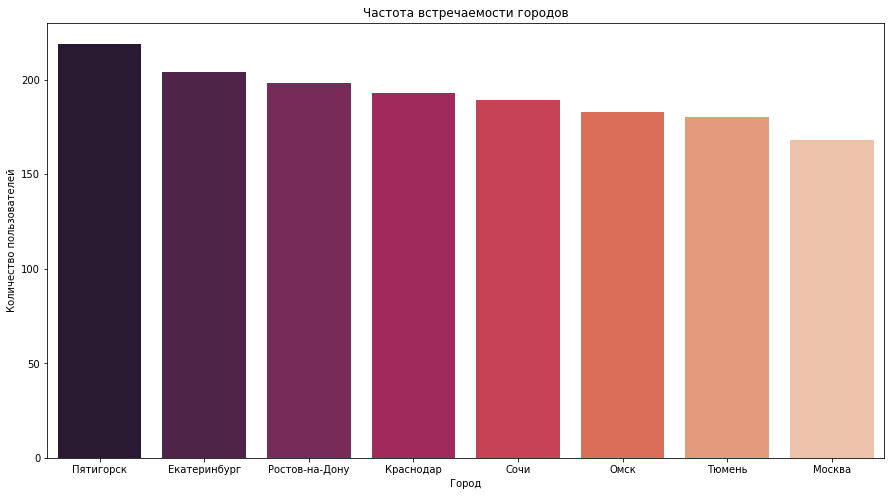

In [19]:
# Установка размера фигуры
plt.figure(figsize=(15, 8))

# Построение столбчатой диаграммы частоты встречаемости городов
sns.countplot(data=users, x='city', order=users['city'].value_counts().index, palette='rocket')

# Заголовок графика
plt.title('Частота встречаемости городов')

# Наименование оси x
plt.xlabel('Город')

# Наименование оси y
plt.ylabel('Количество пользователей')

# Отображение графика
plt.show()

**Вывод**: В топ-3 города с наибольшим количеством пользователей входит Пятигорск, Екатеринбург и Ростов-на-Дону. Что может объясняется, например, более длинным сезоном для аренды самокатов в Пятигорске и Ростове, либо же отсутствием конкурентов в этих городах. Например, в случае Москвы, низкое количество пользователей может быть обусловлено большой конкуренцией в этом бизнесе.

Изучим соотношение пользователей с подпиской и без подписки

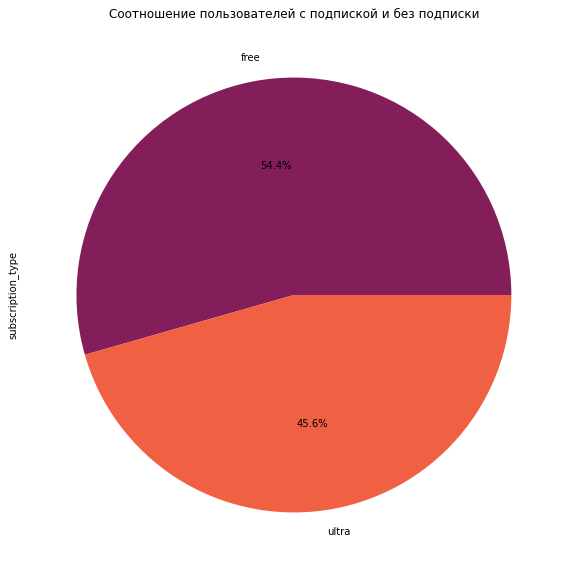

In [20]:
# Создание палитры 'rocket' с двумя цветами
rocket_palette = sns.color_palette('rocket', n_colors=2)

# Установка размера фигуры
plt.figure(figsize=(10, 10))

# Установка цветовой палитры 'rocket'
sns.set_palette('rocket')

# Построение круговой диаграммы соотношения пользователей с подпиской и без подписки
users['subscription_type'].value_counts().plot.pie(colors=rocket_palette, autopct='%1.1f%%')

# Заголовок графика
plt.title('Соотношение пользователей с подпиской и без подписки')

# Отображение графика
plt.show()

**Вывод**: Доля людей, не использующий подписку,  состаивkа 54.4%, что несколько больше, чем людей с подпиской ultra - 45.6%. Это говорит о непопулярности подписки среди пользователей или же неосведомленности о выгодах подписки Ultra.

Изучим возраст пользователей

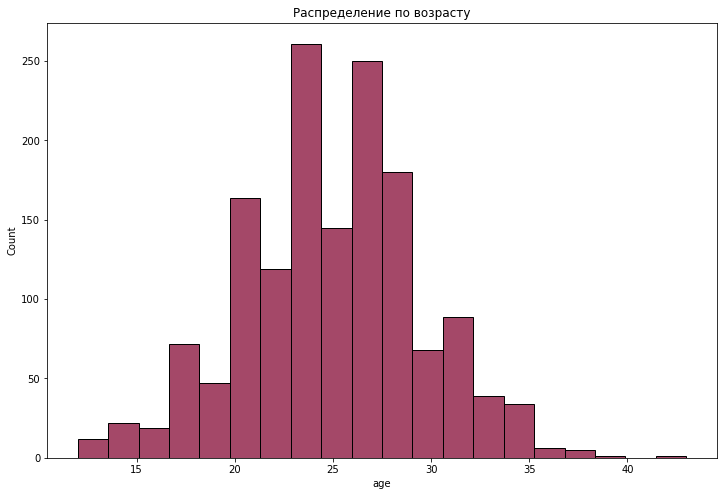

In [21]:
# Установка размера фигуры
plt.figure(figsize=(12, 8))

# Построение гистограммы распределения возраста
sns.histplot(users['age'], bins=20, color='#860A35')

# Заголовок графика
plt.title('Распределение по возрасту')

# Отображение графика
plt.show()

Как мы видим, сервис самокатов очень популярен среди пользователей от 20 до 30 лет. Можно отметить, что низкие показатели в категории 10-20 лет возможно обусловлены возрастными ограничениями со стороны сервиса.

Исследуем расстояние, которое пользователь преодолел за одну поездку.

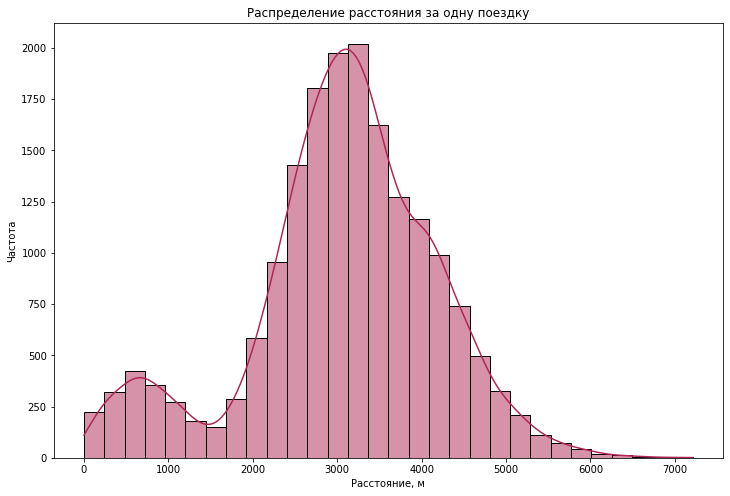

In [22]:
# Установка размера фигуры
plt.figure(figsize=(12, 8))

# Построение гистограммы расстояния за одну поездку
sns.histplot(data=rides, x='distance', bins=30, kde=True, color='#AF2655')

# Заголовок графика
plt.title('Распределение расстояния за одну поездку')

# Наименование оси x
plt.xlabel('Расстояние, м')

# Наименование оси y
plt.ylabel('Частота')

# Отображение графика
plt.show()

Вывод: Как мы видим, пользователи зачастую берут самокат в случаях, если им нужно проделать путь в 500-1000 м или же, наоборот на более длинные расстояние от 2000 до 4000 м. 

Построим гистограмму продолжительности поездок.

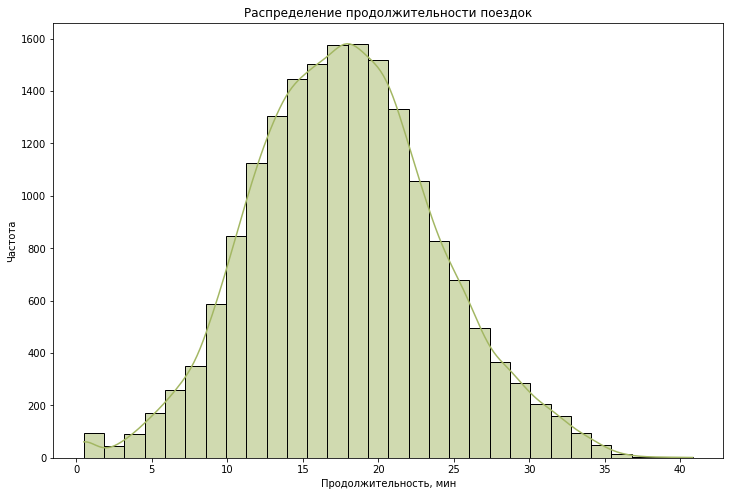

In [23]:
# Установка размера фигуры
plt.figure(figsize=(12, 8))

# Построение гистограммы продолжительности поездок
sns.histplot(data=rides, x='duration', bins=30, kde=True, color='#A3B763')

# Заголовок графика
plt.title('Распределение продолжительности поездок')

# Наименование оси x
plt.xlabel('Продолжительность, мин')

# Наименование оси y
plt.ylabel('Частота')

# Отображение графика
plt.show()

In [24]:
rides['duration'].describe()

count    18068.000000
mean        17.805011
std          6.091051
min          0.500000
25%         13.597563
50%         17.678395
75%         21.724800
max         40.823963
Name: duration, dtype: float64

Вывод: Среднее значение продолжительности поездок составляет примерно 18 минут.
Минимальная продолжительность поездок - 0.5 минут, что возможно связано с тем, что люди, не разобравшись в использовании самоката, быстро завершают поездку. Максимальная продолжительность поездок - 41 минут, однако как видно на графике такие поездки совершаются достаточно редко. 

# Шаг 4. Объединение данных

Для дальнейшей работы нам понадобится объединить информацию из всех трех датафреймов. 

In [25]:
# Объединение датафреймов "users" и "rides" по столбцу "user_id" 
merged_data = pd.merge(users, rides, on='user_id', how='left')

# Отображение первых нескольких строк объединенного датафрема
merged_data.head()

,user_id,name,age,city,subscription_type,distance,duration,date,month
0,1,Кира,22,Тюмень,ultra,4409.919140,25.599769,2021-01-01,1
1,1,Кира,22,Тюмень,ultra,2617.592153,15.816871,2021-01-18,1
2,1,Кира,22,Тюмень,ultra,754.159807,6.232113,2021-04-20,4
3,1,Кира,22,Тюмень,ultra,2694.783254,18.511000,2021-08-11,8
4,1,Кира,22,Тюмень,ultra,4028.687306,26.265803,2021-08-28,8


In [26]:
# Объединение DataFrame'ов "merged_data" и "subscriptions" по столбцу "subscription_type" 
rides_data = pd.merge(merged_data, subscriptions, on='subscription_type', how='left')

# Отображение первых нескольких строк объединенного DataFrame
rides_data.head()

,user_id,name,age,city,subscription_type,distance,duration,date,month,minute_price,start_ride_price,subscription_fee
0,1,Кира,22,Тюмень,ultra,4409.919140,25.599769,2021-01-01,1,6,0,199
1,1,Кира,22,Тюмень,ultra,2617.592153,15.816871,2021-01-18,1,6,0,199
2,1,Кира,22,Тюмень,ultra,754.159807,6.232113,2021-04-20,4,6,0,199
3,1,Кира,22,Тюмень,ultra,2694.783254,18.511000,2021-08-11,8,6,0,199
4,1,Кира,22,Тюмень,ultra,4028.687306,26.265803,2021-08-28,8,6,0,199


In [27]:
users.shape[0]

1534

In [28]:
subscriptions.shape[0]

2

In [29]:
merged_data.shape[0]

18068

In [30]:
rides_data.isnull().sum()

user_id              0
name                 0
age                  0
city                 0
subscription_type    0
distance             0
duration             0
date                 0
month                0
minute_price         0
start_ride_price     0
subscription_fee     0
dtype: int64

In [31]:
rides_data.shape[0]

18068

Объединение прошло корреткно, данные не были ли потеряны, лишних записей или пропусков не появилось.

Создадим два датафрейма с данными о пользователях с подпиской и без подписки. 

In [32]:
# Данные о пользователях без подписки
users_free = rides_data[rides_data['subscription_type'] == 'free'].copy()

# Данные о пользователях с подпиской
users_ultra = rides_data[rides_data['subscription_type'] == 'ultra'].copy()


Визуализируем информацию о расстоянии и времени поездок для пользователей обеих категорий.

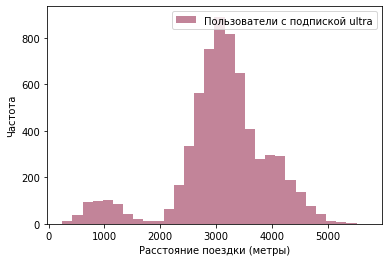

In [33]:
# Гистограмма расстояния поездок для пользователей с подпиской 'ultra'
plt.hist(users_ultra['distance'], bins=30, alpha=0.5, label='Пользователи с подпиской ultra', color='#860A35')

# Наименование оси x
plt.xlabel('Расстояние поездки (метры)')

# Наименование оси y
plt.ylabel('Частота')

# Добавление легенды
plt.legend()

# Отображение гистограммы
plt.show()

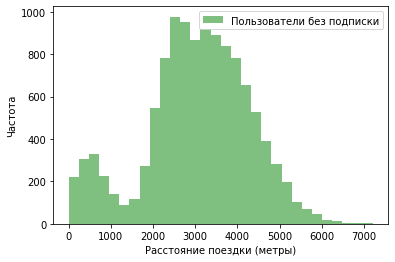

In [34]:
# Гистограмма расстояния поездок для пользователей без подписки
plt.hist(users_free['distance'], bins=30, alpha=0.5, label='Пользователи без подписки', color='green')

# Наименование оси x
plt.xlabel('Расстояние поездки (метры)')

# Наименование оси y
plt.ylabel('Частота')

# Добавление легенды
plt.legend()

# Отображение гистограммы
plt.show()


Как показывает гистограмма, пользователи без подписки совершают поездки на большее расстояние, чем пользователи с подпиской. 

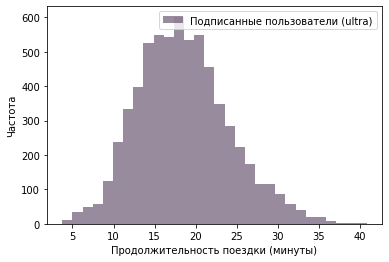

In [35]:
# Гистограмма времени поездок для пользователей с подпиской 'ultra'
plt.hist(users_ultra['duration'], bins=30, alpha=0.5, label='Подписанные пользователи (ultra)')

# Наименование оси x
plt.xlabel('Продолжительность поездки (минуты)')

# Наименование оси y
plt.ylabel('Частота')

# Добавление легенды
plt.legend()

# Отображение гистограммы
plt.show()

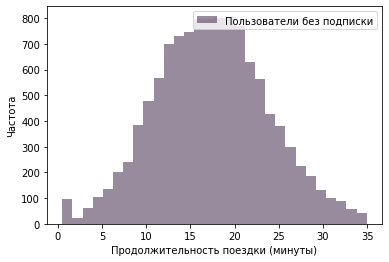

In [36]:
# Гистограмма времени поездок для пользователей без подписки
plt.hist(users_free['duration'], bins=30, alpha=0.5, label='Пользователи без подписки')

# Наименование оси x
plt.xlabel('Продолжительность поездки (минуты)')

# Наименование оси y
plt.ylabel('Частота')

# Добавление легенды
plt.legend()

# Отображение гистограммы
plt.show()

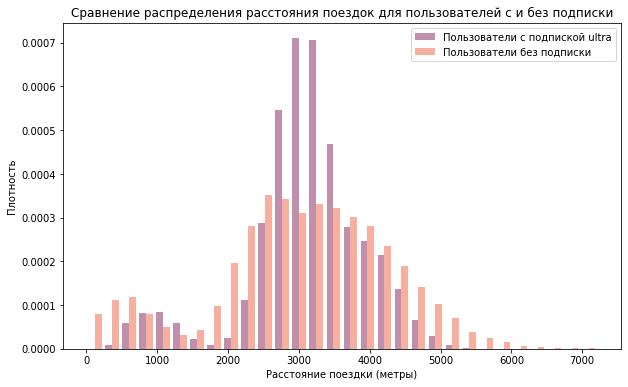

In [37]:
# Создание гистограммы
plt.figure(figsize=(10, 6))

# Добавление цветовой палитры
rocket_palette = sns.color_palette('rocket', n_colors=2)

# Гистограмма расстояния поездок для пользователей с подпиской 'ultra'
plt.hist([users_ultra['distance'], users_free['distance']], bins=30, alpha=0.5, label=['Пользователи с подпиской ultra', 'Пользователи без подписки'], density=True, color=rocket_palette)

# Наименование оси x
plt.xlabel('Расстояние поездки (метры)')

# Наименование оси y
plt.ylabel('Плотность')

# Заголовок
plt.title('Сравнение распределения расстояния поездок для пользователей с и без подписки')

# Добавление легенды
plt.legend()

# Отображение гистограммы
plt.show()

In [38]:
users_ultra['distance'].describe()

count    6500.000000
mean     3115.445388
std       836.895330
min       244.210438
25%      2785.444017
50%      3148.637229
75%      3560.574425
max      5699.769662
Name: distance, dtype: float64

In [39]:
users_free['distance'].describe()

count    11568.000000
mean      3045.495282
std       1246.173806
min          0.855683
25%       2366.562689
50%       3114.648465
75%       3905.697894
max       7211.007745
Name: distance, dtype: float64

У пользователей с подпиской 'ultra' среднее расстояние равно 3115.45 метров, а у пользователей без подписки 'free' среднее расстояние равно 3045.50 метров. Среднее расстояние чуть больше у пользователей с подпиской 'ultra', что достаочно четко отображают графики. 


Стандартное отклонение (std) у пользователей с подпиской 'ultra' составляет 836.90, в то время как у пользователей без подписки 'free' std равно 1246.17. Следовательно, разброс расстояния у пользователей с подпиской 'ultra' меньше.

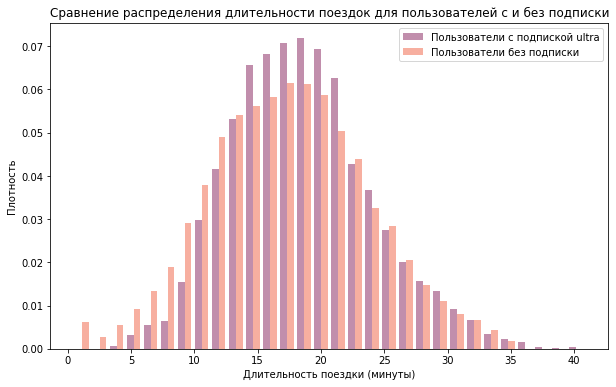

In [40]:
# Создание гистограммы
plt.figure(figsize=(10, 6))

rocket_palette = sns.color_palette('rocket', n_colors=2)


# Гистограмма расстояния поездок для пользователей с подпиской 'ultra'
plt.hist([users_ultra['duration'], users_free['duration']], bins=30, alpha=0.5, label=['Пользователи с подпиской ultra', 'Пользователи без подписки'], density=True, color=rocket_palette)

# Наименование оси x
plt.xlabel('Длительность поездки (минуты)')

# Наименование оси y
plt.ylabel('Плотность')

# Заголовок
plt.title('Сравнение распределения длительности поездок для пользователей с и без подписки')

# Добавление легенды
plt.legend()

# Отображение гистограммы
plt.show()

In [41]:
users_ultra['duration'].describe()

count    6500.000000
mean       18.541985
std         5.572048
min         3.760353
25%        14.524654
50%        18.178153
75%        21.884129
max        40.823963
Name: duration, dtype: float64

In [42]:
users_free['duration'].describe()

count    11568.000000
mean        17.390909
std          6.326803
min          0.500000
25%         12.958437
50%         17.326890
75%         21.594071
max         34.948498
Name: duration, dtype: float64

Пользователи с подпиской 'ultra' имеют стандартное отклонение (std) равное 5.572048, в то время как у пользователей без подписки 'free' std равно 6.326803. Следовательно, у пользователей с подпиской 'ultra' разброс длительности чуть меньше.

У пользователей с подпиской 'ultra' медиана равна 18.178153, а у пользователей без подписки 'free' медиана равна 17.326890. Медианы близки, но у пользователей с подпиской 'ultra' она чуть больше.

В целом, мы можем заключить, что графики не так сильно отличаются друг от друга.

# Шаг 5. Подсчёт выручки

Для подсчета выручки создадим сводную таблицу по параметрам "user_id" и "month".


In [43]:
# ИСПРАВИЛА Округление каждого значения из столбца "duration" с использованием 'потолка'
rides_data['duration'] = np.ceil(rides_data['duration'])

In [44]:
# Создание сводной таблицы "revenue" по параметрам "user_id" и "month"
revenue = rides_data.pivot_table(index=['user_id', 'month'],
                                values=['distance', 'duration', 'name', 'subscription_type', 'minute_price', 'start_ride_price', 'subscription_fee'],
                                aggfunc={'distance': 'sum', 'duration': 'sum', 'name': 'count', 'subscription_type': 'first', 'minute_price': 'first', 'start_ride_price': 'first', 'subscription_fee': 'first'})



# Переименование столбца "name" в "rides_count"
revenue.rename(columns = {'name':'rides_count'}, inplace = True)

# Отображение первых 5 строк сводной таблицы
revenue.head(5)

# Создание нового столбца "monthly_revenue" в сводной таблице
revenue['monthly_revenue'] = revenue['duration'] * revenue['minute_price'] + revenue['start_ride_price'] * revenue['rides_count'] + revenue['subscription_fee']

# Отображение первых 5 строк сводной таблицы с добавленным столбцом "monthly_revenue"
revenue.head()

distance  duration  minute_price  rides_count  \
user_id month                                                     
1       1      7027.511294      42.0             6            2   
        4       754.159807       7.0             6            1   
        8      6723.470560      46.0             6            2   
        10     5809.911100      32.0             6            2   
        11     7003.499363      56.0             6            3   

               start_ride_price  subscription_fee subscription_type  \
user_id month                                                         
1       1                     0               199             ultra   
        4                     0               199             ultra   
        8                     0               199             ultra   
        10                    0               199             ultra   
        11                    0               199             ultra   

               monthly_revenue  
user_id month                   
1       1                451.0  
        4                241.0  
        8                475.0  
        10               391.0  
        11               535.0

In [45]:
revenue.isnull().sum()

distance             0
duration             0
minute_price         0
rides_count          0
start_ride_price     0
subscription_fee     0
subscription_type    0
monthly_revenue      0
dtype: int64

Пропусков нет.

На основе этого датафрейма создадим отдельные датафреймы с информацией о месячной выручке для пользователей с подпиской 'ultra' и 'free'

In [46]:
# Создание отдельных DataFrame для пользователей с подпиской 'ultra' и 'free'
revenue_ultra = revenue[revenue['subscription_type'] == 'ultra'].copy()
revenue_free = revenue[revenue['subscription_type'] == 'free'].copy()

# Расчет 'monthly_revenue' для подсписки 'ultra'
revenue_ultra['monthly_revenue'] = (
    revenue_ultra['duration'] * revenue_ultra['minute_price'] +
    revenue_ultra['start_ride_price'] * revenue_ultra['rides_count'] +
    revenue_ultra['subscription_fee']
)

# Отображение первых 10 строк DataFrame 'revenue_ultra'
revenue_ultra.head(10)

distance  duration  minute_price  rides_count  \
user_id month                                                      
1       1       7027.511294      42.0             6            2   
        4        754.159807       7.0             6            1   
        8       6723.470560      46.0             6            2   
        10      5809.911100      32.0             6            2   
        11      7003.499363      56.0             6            3   
        12      6751.629942      28.0             6            2   
2       3      10187.723006      63.0             6            3   
        4       6164.381824      40.0             6            2   
        6       3255.338202      14.0             6            1   
        7       6780.722964      48.0             6            2   

               start_ride_price  subscription_fee subscription_type  \
user_id month                                                         
1       1                     0               199             ultra   
        4                     0               199             ultra   
        8                     0               199             ultra   
        10                    0               199             ultra   
        11                    0               199             ultra   
        12                    0               199             ultra   
2       3                     0               199             ultra   
        4                     0               199             ultra   
        6                     0               199             ultra   
        7                     0               199             ultra   

               monthly_revenue  
user_id month                   
1       1                451.0  
        4                241.0  
        8                475.0  
        10               391.0  
        11               535.0  
        12               367.0  
2       3                577.0  
        4                439.0  
        6                283.0  
        7                487.0

In [47]:
# Расчет 'monthly_revenue' для подсписки 'free'
revenue_free['monthly_revenue'] = (
    revenue_free['duration'] * revenue_free['minute_price'] +
    revenue_free['start_ride_price'] * revenue_free['rides_count'] +
    revenue_free['subscription_fee']
)
revenue_free.head()

distance  duration  minute_price  rides_count  \
user_id month                                                      
700     1       2515.690719      15.0             8            1   
        2      13446.659764      89.0             8            5   
        3       3798.334905      19.0             8            1   
        4       2984.551206      16.0             8            1   
        6       5927.650988      29.0             8            2   

               start_ride_price  subscription_fee subscription_type  \
user_id month                                                         
700     1                    50                 0              free   
        2                    50                 0              free   
        3                    50                 0              free   
        4                    50                 0              free   
        6                    50                 0              free   

               monthly_revenue  
user_id month                   
700     1                170.0  
        2                962.0  
        3                202.0  
        4                178.0  
        6                332.0

# Шаг 6. Проверка гипотез

**Важно понять, тратят ли пользователи с подпиской больше времени на поездки? Если да, то пользователи с подпиской могут быть «выгоднее» для компании. Проверьте гипотезу. Используйте исходные данные о продолжительности каждой сессии — отдельно для подписчиков и тех, у кого нет подписки.**

Гипотезы для проверки могут быть сформулированы так:

**Нулевая гипотеза (H0)**:
Средняя продолжительность поездок для пользователей с подпиской равна средней продолжительности поездок для пользователей без подписки.

**Альтернативная гипотеза (H1)**:
Средняя продолжительность поездок для пользователей с подпиской больше средней продолжительности поездок чем продолжительность поездок пользователей без подписки. 

Использем статистический тест и проверим, есть ли статистически значимые различия в продолжительности поездок между двумя группами пользователей.






In [48]:
# Выделение продолжительности поездок для пользователей с подпиской 'ultra' и 'free'
ultra_duration = users_ultra['duration']
free_duration = users_free['duration']

# Установка уровня значимости
alpha = 0.05

# Проведение t-теста для проверки гипотезы о равенстве средних
results = st.ttest_ind(ultra_duration, free_duration, alternative='greater')

# Вывод значения p-значения
print('p-значение:', results.pvalue)

# Проверка условия и вывод результата
if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не получилось отвергнуть нулевую гипотезу') 

p-значение: 1.2804098316645618e-34
Отвергаем нулевую гипотезу


Получили значительно маленькое p-значение (1.28e-34), что говорит о статистической значимости различий в продолжительности поездок между пользователями с подпиской и пользователями без подписки.

Мы можем отвергнуть нулевую гипотезу о равенстве средних и принять альтернативную гипотезу, что средняя продолжительность поездок для пользователей с подпиской 'ultra' больше, чем для пользователей без подписки 'free'.

**2. Расстояние одной поездки в 3130 метров — оптимальное с точки зрения износа самоката. Можно ли сказать, что среднее расстояние, которое проезжают пользователи с подпиской за одну поездку, не превышает 3130 метров? Проверьте гипотезу и сделайте выводы.**


Для проверки данной гипотезы можно использовать одновыборочный t-тест. Гипотезы сформулируем так:

**Нулевая гипотеза (H0)**: Среднее расстояние, которое проезжают пользователи с подпиской за одну поездку, равно 3130 метров.

**Альтернативная гипотеза (H1)**: Среднее расстояние, которое проезжают пользователи с подпиской за одну поездку, больше 3130 метрам.


In [49]:
# Выделение расстояния поездок для пользователей с подпиской 'ultra'
ultra_distance = users_ultra['distance']

# Интересующее нас значение для сравнения
interested_value = 3130 

# Установка уровня значимости
alpha = 0.05

# Проведение одновыборочного t-теста для проверки гипотезы о среднем значении
results = st.ttest_1samp(ultra_distance, interested_value, alternative='greater')

# Вывод значения p-значения
print('p-значение:', results.pvalue)

# Проверка условия и вывод результата
if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не получилось отвергнуть нулевую гипотезу')

p-значение: 0.9195368847849785
Не получилось отвергнуть нулевую гипотезу


Полученное p-значение равное 0.9195368847849785 говорит о том, что нет статистически значимых различий между средним расстоянием поездок пользователей с подпиской 'ultra' и установленным оптимальным расстоянием 3130 метров.

На основе данного теста мы не можем сделать вывод о том, что среднее расстояние за одну поездку для пользователей с подпиской 'ultra' близко к 3130 метрам.

**Проверьте гипотезу о том, будет ли помесячная выручка от пользователей с подпиской по месяцам выше, чем выручка от пользователей без подписки. Сделайте вывод.**

Для проверки этой гипотезы будем использовать двухвыборочный t-тест для независимых выборок. Гипотезы формулируются следующим образом:

**Нулевая гипотеза (H0)**: Средняя помесячная выручка от пользователей с подпиской равна средней помесячной выручке от пользователей без подписки.

**Альтернативная гипотеза (H1)**: Средняя помесячная выручка от пользователей с подпиской выше, чем средняя помесячная выручка от пользователей без подписки.


In [50]:

# Уровень значимости
alpha = 0.05

# Проведение t-теста для двух независимых выборок с альтернативной гипотезой 'greater'
result = st.ttest_ind(revenue_ultra['monthly_revenue'], revenue_free['monthly_revenue'], alternative='greater', equal_var=False)

# Вывод значения p-значения
print('p-значение:', result.pvalue)

# Проверка условия и вывод результата
if result.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не получилось отвергнуть нулевую гипотезу')

p-значение: 8.874140893976874e-40
Отвергаем нулевую гипотезу


In [51]:
# Уровень значимости
alpha = 0.05

# Проведение t-теста для двух независимых выборок с альтернативной гипотезой 'greater'
result = st.ttest_ind(revenue.query('subscription_type == "ultra"')['monthly_revenue'],
                      revenue.query('subscription_type == "free"')['monthly_revenue'],
                      alternative='greater', equal_var=False)

# Вывод значения p-значения
print('p-значение:', result.pvalue)

# Проверка условия и вывод результата
if result.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не получилось отвергнуть нулевую гипотезу')

p-значение: 8.874140893976874e-40
Отвергаем нулевую гипотезу


Результаты теста (p-значение: 8.874140893976874e-40) позволяют отвергнуть нулевую гипотезу, то есть средняя помесячная выручка от пользователей с подпиской выше, чем средняя помесячная выручка от пользователей без подписки.

**Представьте такую ситуацию: техническая команда сервиса обновила сервера, с которыми взаимодействует мобильное приложение. Она надеется, что из-за этого количество обращений в техподдержку значимо снизилось. Некоторый файл содержит для каждого пользователя данные о количестве обращений до обновления и после него. Какой тест вам понадобился бы для проверки этой гипотезы?**


Для проверки гипотезы о том, что обновление серверов привело к значимому снижению количества обращений в техподдержку, можно использовать t-тест для зависимых (парных) выборок - ttest_rel. 

Гипотезы для теста:

Нулевая гипотеза (H0): Среднее количество обращений до обновления серверов равно среднему количеству обращений после обновления серверов.

Альтернативная гипотеза (H1): Среднее количество обращений до обновления серверов отличается от среднего количества обращений после обновления серверов.
    
Гипотеза в этом случае одностронняя так, как команда надеется на снижение количества обращений в техподдержку.

# Вывод

В ходе анализа данных были проведены следующие шаги:

~Изучили и обработали данные из трех таблиц: users, rides, и subscriptions, изменили тип данных, где это было необходимо.

~Удалили дубликаты в таблице users, а также провели проверку наличия дубликатов в таблицах rides и subscriptions.

~Выявили топ-3 города с наибольшим количеством пользователей: Пятигорск, Екатеринбург и Ростов-на-Дону.

~Оценили доля пользователей с подпиской (45.6%) и без подписки (54.4%).

~Провели анализ возрастных групп - пользователи в возрасте от 20 до 30 лет являются наиболее активными пользователями сервиса.

~Проанализировали продолжительность поездок:построили гистрограмму и изучили характеристики продолжительности поездок для пользователей с подпиской и без.

~Провели Анализ расстояния поездок:пользователи, как правило, берут самокаты на расстояния от 500 до 4000 метров.


В ходе статистического анализа проверили три гипотезы:

~Проверили гипотезу о том, тратят ли пользователи с подпиской больше времени на поездки. **Результат**: средняя продолжительность поездок для пользователей с подпиской 'ultra' больше, чем для пользователей без подписки 'free'.

~Проверили гипотезу о том, что среднее расстояние для пользователей с подпиской не превышает оптимальных 3130 метров. **Результат**: мы не можем сделать вывод о том, что среднее расстояние за одну поездку для пользователей с подпиской 'ultra' близко к 3130 метрам.

~Проверили гипотезу о том, будет ли помесячная выручка от пользователей с подпиской выше, чем у пользователей без подписки.**Результат**: средняя помесячная выручка от пользователей с подпиской выше, чем средняя помесячная выручка от пользователей без подписки.

Обобщая анализ, можно сделать вывод о том, что продвижение подписки 'ultra' среди пользователей приносит бизнесу больше выручки. Однако в будущем было бы полезно провести исследование стоимости и обслуживания самокатов и выручки, получаемой за счет клиентов с подпиской, для оценки рентабельности бизнеса и эффективности модели.